# 聲納影像異常偵測系統
**方法：PatchCore（無監督異常偵測）**

## 流程概覽
1. 環境安裝與設定
2. 參數設定
3. 特徵提取器（WideResNet50）
4. Memory Bank 建立（用正常影像訓練）
5. 影片推論
6. 結果視覺化與閾值調整

## Cell 1 — 安裝套件

In [ ]:
# 第一次執行時需要安裝，之後可以跳過
!pip install torch torchvision opencv-python-headless tqdm matplotlib scikit-learn

## Cell 2 — 匯入套件

In [11]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
from PIL import Image
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

print(f"PyTorch 版本：{torch.__version__}")
print(f"CUDA 可用：{torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU：{torch.cuda.get_device_name(0)}")

PyTorch 版本：1.12.1
CUDA 可用：True
GPU：NVIDIA GeForce RTX 3090


## Cell 3 — 參數設定
**所有參數集中在這裡，方便調整**

In [13]:
# ============================================================
#  請根據你的環境修改以下路徑與參數
# ============================================================

# --- 資料路徑 ---
NORMAL_IMAGE_DIR = "./normal"        # 正常聲納影像資料夾（582 張）
MEMORY_BANK_PATH = "./memory_bank.pt"     # Memory bank 儲存路徑

# --- 影像前處理 ---
IMAGE_SIZE = 224                          # Resize 後的尺寸
MEAN = [0.485, 0.456, 0.406]             # ImageNet 標準化參數
STD  = [0.229, 0.224, 0.225]

# --- PatchCore 參數 ---
SAMPLE_RATIO   = 0.1                      # 隨機取樣保留比例（測試用，流程穩定後可換 CoreSet）
KNN_N_NEIGHBORS = 9                       # 取最近 N 個鄰居的距離

# --- Stage 1 規則篩選 ---
BRIGHTNESS_LOW  = 5                       # 平均亮度低於此 → 無畫面（太暗）
BRIGHTNESS_HIGH = 250                     # 平均亮度高於此 → 無畫面（過曝）

# --- 影片處理 ---
SAMPLE_FRAMES = 20                        # 每段影片均勻取樣幾幀
AGGREGATION_PERCENTILE = 90              # 聚合策略：取第幾百分位的異常分數

# --- 異常判斷閾值（手動調整）---
ANOMALY_THRESHOLD = 0.5                   # 異常分數 > 此值 → 標記為異常（初始值，需校準）

# --- 裝置 ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用裝置：{DEVICE}")

使用裝置：cuda


## Cell 4 — 特徵提取器
使用 WideResNet50 的 `layer2` + `layer3` 中間層特徵

In [14]:
class FeatureExtractor(nn.Module):
    """
    從 WideResNet50 提取 layer2 + layer3 的中間層特徵
    - layer2：捕捉紋理、細節特徵
    - layer3：捕捉結構、形狀特徵
    兩層融合後能更全面描述正常影像的分布
    """
    def __init__(self):
        super().__init__()
        backbone = models.wide_resnet50_2(weights=models.Wide_ResNet50_2_Weights.IMAGENET1K_V1)
        
        # 只保留需要的層，凍結所有參數
        self.layer0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool)
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        
        # 凍結參數（不需要訓練）
        for param in self.parameters():
            param.requires_grad = False
        
        self.eval()
    
    def forward(self, x):
        x = self.layer0(x)
        x = self.layer1(x)
        feat2 = self.layer2(x)   # shape: [B, 512, H/8, W/8]
        feat3 = self.layer3(feat2)  # shape: [B, 1024, H/16, W/16]
        return feat2, feat3


def fuse_features(feat2, feat3):
    """
    將 layer2 和 layer3 的特徵融合：
    把 feat3 上採樣到 feat2 的空間尺寸，然後 concat
    """
    target_h, target_w = feat2.shape[2], feat2.shape[3]
    feat3_up = nn.functional.interpolate(
        feat3, size=(target_h, target_w), mode="bilinear", align_corners=False
    )
    fused = torch.cat([feat2, feat3_up], dim=1)  # [B, 1536, H, W]
    return fused


def extract_patch_features(fused_feat):
    """
    將 feature map 展平成 patch 特徵向量集合
    [B, C, H, W] → [B*H*W, C]
    """
    B, C, H, W = fused_feat.shape
    # [B, C, H, W] → [B, H*W, C] → [B*H*W, C]
    patches = fused_feat.permute(0, 2, 3, 1).reshape(-1, C)
    return patches.cpu().numpy()


# 初始化特徵提取器
extractor = FeatureExtractor().to(DEVICE)
print("✅ 特徵提取器初始化完成")

# 影像前處理 transform
transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

✅ 特徵提取器初始化完成


## Cell 5 — Stage 1：規則篩選函式
快速偵測「無畫面」（全黑/過曝）的幀，不需要模型

In [15]:
def is_blank_frame(frame_bgr, low=BRIGHTNESS_LOW, high=BRIGHTNESS_HIGH):
    """
    規則篩選：判斷是否為無畫面幀
    - 轉成灰階後計算平均亮度
    - 過暗（< low）或過亮（> high）都視為異常
    回傳：(is_blank: bool, mean_brightness: float)
    """
    gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    mean_brightness = gray.mean()
    is_blank = (mean_brightness < low) or (mean_brightness > high)
    return is_blank, mean_brightness

print("✅ Stage 1 規則篩選函式準備完成")

✅ Stage 1 規則篩選函式準備完成


## Cell 6 — 隨機取樣（快速版）
隨機從所有特徵中取樣子集來建立 Memory Bank

> **說明：** 這是測試用的快速版本，速度比 CoreSet 快 10 倍以上。
> 流程穩定、閾值調好之後，可以再換成 CoreSet 版本提升精度。

In [16]:
def random_sampling(features: np.ndarray, ratio: float = SAMPLE_RATIO) -> np.ndarray:
    """
    隨機取樣：快速壓縮 Memory Bank
    - features: [N, C] 的特徵矩陣
    - ratio: 保留比例（0.1 = 保留 10%）
    """
    n_select = max(1, int(len(features) * ratio))
    indices = np.random.choice(len(features), n_select, replace=False)
    print(f"  隨機取樣：從 {len(features)} 個特徵中挑選 {n_select} 個")
    return features[indices]

print("✅ 隨機取樣函式準備完成")

✅ 隨機取樣函式準備完成


## Cell 7 — 建立 Memory Bank（Training Phase）
**只需執行一次**，結果會存成 `memory_bank.pt`

In [17]:
def build_memory_bank(image_dir: str, save_path: str):
    """
    從正常影像資料夾建立 Memory Bank：
    1. 讀取所有正常影像
    2. 提取 patch 特徵
    3. 隨機取樣壓縮
    4. 建立 sklearn NearestNeighbors 並儲存
    """
    image_paths = sorted([
        p for p in Path(image_dir).glob("*")
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]
    ])
    
    if len(image_paths) == 0:
        raise ValueError(f"在 {image_dir} 找不到影像檔案，請確認路徑是否正確")
    
    print(f"找到 {len(image_paths)} 張正常影像")
    
    all_patch_features = []
    
    with torch.no_grad():
        for img_path in tqdm(image_paths, desc="提取特徵"):
            # 讀取並前處理
            img = Image.open(img_path).convert("RGB")
            tensor = transform(img).unsqueeze(0).to(DEVICE)
            
            # 提取特徵
            feat2, feat3 = extractor(tensor)
            fused = fuse_features(feat2, feat3)
            patches = extract_patch_features(fused)  # [H*W, C]
            all_patch_features.append(patches)
    
    # 合併所有特徵
    all_features = np.concatenate(all_patch_features, axis=0).astype(np.float32)
    print(f"原始特徵數量：{len(all_features)}")
    
    # 隨機取樣壓縮
    memory_bank = random_sampling(all_features, ratio=SAMPLE_RATIO)
    print(f"壓縮後 Memory Bank 大小：{len(memory_bank)}")
    
    # 建立 NearestNeighbors index
    print("建立 NearestNeighbors index...")
    knn = NearestNeighbors(n_neighbors=KNN_N_NEIGHBORS, metric="euclidean", algorithm="auto", n_jobs=-1)
    knn.fit(memory_bank)
    print(f"✅ NearestNeighbors 建立完成")
    
    # 儲存
    torch.save({
        "memory_bank": memory_bank,
        "feature_dim": memory_bank.shape[1],
    }, save_path)
    
    print(f"\n✅ Memory Bank 已儲存至 {save_path}")
    return knn


# 執行建立（第一次才需要執行）
# 如果已有 memory_bank.pt，可以跳到下一個 Cell 直接載入
if not Path(MEMORY_BANK_PATH).exists():
    knn_index = build_memory_bank(NORMAL_IMAGE_DIR, MEMORY_BANK_PATH)
else:
    print(f"Memory Bank 已存在（{MEMORY_BANK_PATH}），跳過建立。")
    print("若要重建，請刪除該檔案後重新執行此 Cell。")

Memory Bank 已存在（./memory_bank.pt），跳過建立。
若要重建，請刪除該檔案後重新執行此 Cell。


## Cell 8 — 載入 Memory Bank

In [18]:
def load_memory_bank(save_path: str):
    """
    載入已儲存的 Memory Bank，重建 NearestNeighbors index
    """
    data = torch.load(save_path, map_location="cpu")
    memory_bank = data["memory_bank"]
    
    knn = NearestNeighbors(n_neighbors=KNN_N_NEIGHBORS, metric="euclidean", algorithm="auto", n_jobs=-1)
    knn.fit(memory_bank)
    
    print(f"✅ Memory Bank 載入完成，共 {len(memory_bank)} 個向量")
    return knn


knn_index = load_memory_bank(MEMORY_BANK_PATH)

✅ Memory Bank 載入完成，共 45628 個向量


## Cell 9 — 單幀異常分數計算

In [20]:
def compute_frame_anomaly_score(frame_bgr: np.ndarray, index) -> float:
    """
    對單一幀計算異常分數：
    1. 前處理
    2. 提取特徵
    3. FAISS nearest neighbor 搜尋
    4. 取最大 patch 異常分數作為該幀的分數
    """
    # BGR → RGB → PIL → Transform
    img_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb)
    tensor = transform(img_pil).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        feat2, feat3 = extractor(tensor)
        fused = fuse_features(feat2, feat3)
        patches = extract_patch_features(fused).astype(np.float32)  # [N_patches, C]
    
    # FAISS 搜尋最近鄰
    distances, _ = index.kneighbors(patches)  # [N_patches, k]
    
    # 每個 patch 的異常分數 = 最近鄰距離的平均（取 k 個）
    patch_scores = distances.mean(axis=1)  # [N_patches]
    
    # 該幀的異常分數 = 最異常的 patch 分數（取最大值）
    frame_score = patch_scores.max()
    
    return float(frame_score)

print("✅ 單幀異常分數計算函式準備完成")

✅ 單幀異常分數計算函式準備完成


## Cell 10 — 影片推論主函式

In [21]:
def analyze_video(video_path: str, knn, threshold: float = ANOMALY_THRESHOLD):
    """
    分析一段影片：
    1. Stage 1：規則篩選（全黑/過曝）
    2. Stage 2：PatchCore 異常偵測
    3. 聚合多幀分數 → 整段判斷
    
    回傳：
    {
        'video_path': str,
        'is_anomaly': bool,
        'anomaly_score': float,        # P90 聚合分數
        'frame_scores': list[float],   # 每幀分數
        'sampled_frame_ids': list[int],# 取樣的幀索引
        'stage1_triggered': bool,      # 是否被規則篩選攔截
        'fps': float,
        'total_frames': int,
    }
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"無法開啟影片：{video_path}")
    
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"影片：{Path(video_path).name} | FPS: {fps:.1f} | 總幀數: {total_frames}")
    
    # 均勻取樣幀的索引
    sample_ids = np.linspace(0, total_frames - 1, SAMPLE_FRAMES, dtype=int).tolist()
    
    frame_scores = []
    stage1_triggered = False
    stage1_frame_id = None
    
    for frame_id in tqdm(sample_ids, desc="分析幀"):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
        ret, frame = cap.read()
        if not ret:
            continue
        
        # Stage 1：規則篩選
        is_blank, brightness = is_blank_frame(frame)
        if is_blank:
            stage1_triggered = True
            stage1_frame_id = frame_id
            print(f"  ⚠️  Stage 1 觸發！幀 {frame_id}，亮度={brightness:.1f}")
            frame_scores.append(99999.0)  # 給一個極大分數
            continue
        
        # Stage 2：PatchCore 異常分數
        score = compute_frame_anomaly_score(frame, knn)
        frame_scores.append(score)
    
    cap.release()
    
    if len(frame_scores) == 0:
        print("警告：沒有成功讀取任何幀")
        return None
    
    # 聚合：取 P90 分數（排除 Stage1 的極大值做正規聚合）
    valid_scores = [s for s in frame_scores if s < 99999.0]
    if len(valid_scores) > 0:
        aggregated_score = np.percentile(valid_scores, AGGREGATION_PERCENTILE)
    else:
        aggregated_score = 99999.0
    
    is_anomaly = stage1_triggered or (aggregated_score > threshold)
    
    result = {
        "video_path": video_path,
        "is_anomaly": is_anomaly,
        "anomaly_score": aggregated_score,
        "frame_scores": frame_scores,
        "sampled_frame_ids": sample_ids,
        "stage1_triggered": stage1_triggered,
        "fps": fps,
        "total_frames": total_frames,
    }
    
    status = "🔴 異常" if is_anomaly else "🟢 正常"
    print(f"\n結果：{status} | 異常分數：{aggregated_score:.4f} | 閾值：{threshold}")
    return result

print("✅ 影片推論函式準備完成")

✅ 影片推論函式準備完成


## Cell 11 — 結果視覺化函式

In [22]:
def visualize_result(result: dict, threshold: float = ANOMALY_THRESHOLD):
    """
    視覺化影片分析結果：
    - 每幀異常分數折線圖
    - 閾值線
    - 異常幀標記
    """
    scores = result["frame_scores"]
    frame_ids = result["sampled_frame_ids"]
    
    # 顯示分數（Stage1 的 99999 改顯示為較大的值以便視覺化）
    display_scores = [min(s, threshold * 3) for s in scores]
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # 每幀分數
    colors = ["red" if s > threshold else "steelblue" for s in scores]
    ax.bar(range(len(scores)), display_scores, color=colors, alpha=0.7, label="幀異常分數")
    ax.plot(range(len(scores)), display_scores, color="navy", linewidth=1.5, marker="o", markersize=4)
    
    # 閾值線
    ax.axhline(y=threshold, color="red", linestyle="--", linewidth=2, label=f"閾值 = {threshold}")
    
    # P90 線
    valid_scores = [s for s in scores if s < 99999.0]
    p90 = np.percentile(valid_scores, AGGREGATION_PERCENTILE) if valid_scores else 0
    ax.axhline(y=p90, color="orange", linestyle="-.", linewidth=2, label=f"P90 聚合分數 = {p90:.4f}")
    
    # X 軸標籤：幀索引
    ax.set_xticks(range(len(scores)))
    ax.set_xticklabels([str(f) for f in frame_ids], rotation=45, fontsize=8)
    
    status = "🔴 異常" if result["is_anomaly"] else "🟢 正常"
    ax.set_title(f"{Path(result['video_path']).name} — 判斷結果：{status}", fontsize=13)
    ax.set_xlabel("幀索引")
    ax.set_ylabel("異常分數")
    
    normal_patch = mpatches.Patch(color="steelblue", alpha=0.7, label="正常幀")
    anomaly_patch = mpatches.Patch(color="red", alpha=0.7, label="異常幀")
    ax.legend(handles=[normal_patch, anomaly_patch,
                        plt.Line2D([0], [0], color="red", linestyle="--", label=f"閾值={threshold}"),
                        plt.Line2D([0], [0], color="orange", linestyle="-.", label=f"P90={p90:.4f}")])
    
    plt.tight_layout()
    plt.show()

print("✅ 視覺化函式準備完成")

✅ 視覺化函式準備完成


## Cell 12 — 單一影片推論（快速測試）

影片：2026_03_19_15_55_15_3_video.mp4 | FPS: 20.0 | 總幀數: 200


分析幀: 100%|██████████| 20/20 [00:10<00:00,  1.86it/s]


結果：🔴 異常 | 異常分數：4.9732 | 閾值：0.5



C:\Users\user\AppData\Local\Temp\ipykernel_63112\2290292755.py:44: UserWarning: Glyph 24128 (\N{CJK UNIFIED IDEOGRAPH-5E40}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\2290292755.py:44: UserWarning: Glyph 32034 (\N{CJK UNIFIED IDEOGRAPH-7D22}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\2290292755.py:44: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\2290292755.py:44: UserWarning: Glyph 30064 (\N{CJK UNIFIED IDEOGRAPH-7570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\2290292755.py:44: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\2290292755.py:44: UserWarning: Glyph 20998 (\N{CJK

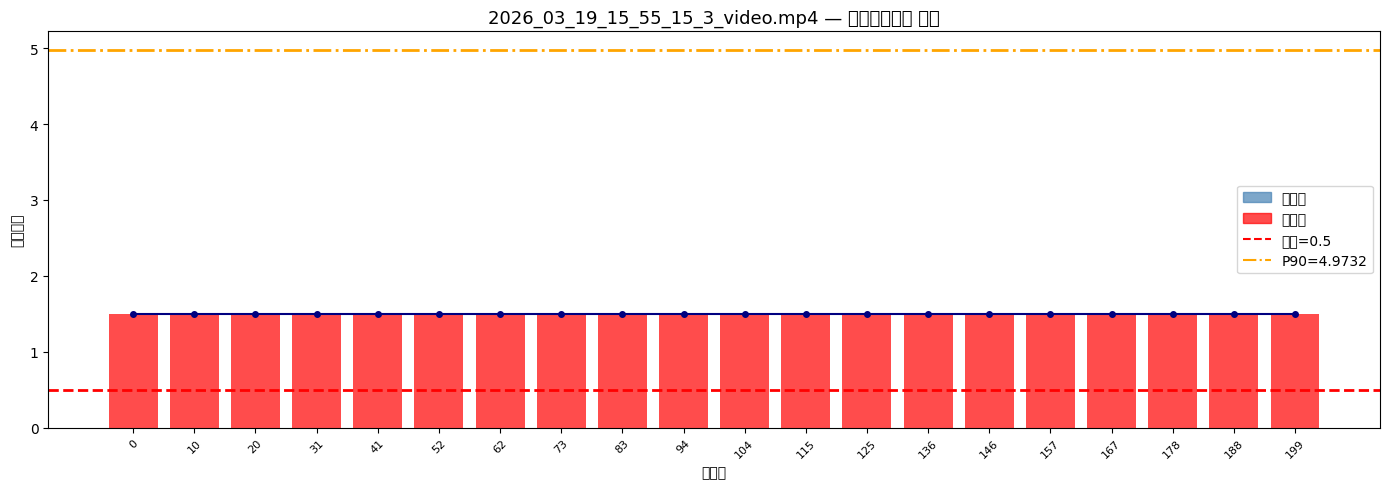

In [25]:
# 修改成你的影片路徑
TEST_VIDEO_PATH = "sorted_data/normal/2026_03_19_15_55_15_3_video.mp4"

result = analyze_video(TEST_VIDEO_PATH, knn_index, threshold=ANOMALY_THRESHOLD)

if result:
    visualize_result(result, threshold=ANOMALY_THRESHOLD)

## Cell 13 — 批次推論（驗證集評估）
用正常 + 異常影片來評估效果，並找最佳閾值

In [26]:
# ============================================================
#  設定驗證集路徑
#  資料夾結構：
#    ./data/val/normal/  → 放正常影片
#    ./data/val/anomaly/ → 放異常影片（未入水、無畫面）
# ============================================================
VAL_NORMAL_DIR  = "sorted_data/normal"
VAL_ANOMALY_DIR = "sorted_data/anomaly"

VIDEO_EXTENSIONS = [".mp4", ".avi", ".mov", ".mkv"]

def get_video_paths(directory):
    return sorted([
        str(p) for p in Path(directory).glob("*")
        if p.suffix.lower() in VIDEO_EXTENSIONS
    ])

normal_videos  = get_video_paths(VAL_NORMAL_DIR)
anomaly_videos = get_video_paths(VAL_ANOMALY_DIR)
print(f"正常影片：{len(normal_videos)} 支 | 異常影片：{len(anomaly_videos)} 支")

all_results = []
all_labels  = []   # 0 = 正常, 1 = 異常
all_scores  = []

print("\n--- 分析正常影片 ---")
for vp in normal_videos:
    r = analyze_video(vp, knn_index, threshold=ANOMALY_THRESHOLD)
    if r:
        all_results.append(r)
        all_labels.append(0)
        all_scores.append(r["anomaly_score"])

print("\n--- 分析異常影片 ---")
for vp in anomaly_videos:
    r = analyze_video(vp, knn_index, threshold=ANOMALY_THRESHOLD)
    if r:
        all_results.append(r)
        all_labels.append(1)
        all_scores.append(r["anomaly_score"])

print(f"\n✅ 批次推論完成，共分析 {len(all_results)} 支影片")

正常影片：21 支 | 異常影片：47 支

--- 分析正常影片 ---
影片：2026_03_19_15_40_13_3_video.mp4 | FPS: 20.0 | 總幀數: 200


分析幀: 100%|██████████| 20/20 [00:11<00:00,  1.81it/s]



結果：🔴 異常 | 異常分數：6.8249 | 閾值：0.5
影片：2026_03_19_15_40_23_3_video.mp4 | FPS: 20.0 | 總幀數: 200


分析幀: 100%|██████████| 20/20 [00:10<00:00,  1.83it/s]



結果：🔴 異常 | 異常分數：6.7533 | 閾值：0.5
影片：2026_03_19_15_40_33_3_video.mp4 | FPS: 20.0 | 總幀數: 200


...


結果：🔴 異常 | 異常分數：7.1248 | 閾值：0.5
影片：nuwater (3).mp4 | FPS: 20.0 | 總幀數: 200


分析幀: 100%|██████████| 20/20 [00:11<00:00,  1.67it/s]



結果：🔴 異常 | 異常分數：7.1675 | 閾值：0.5
影片：nuwater (4).mp4 | FPS: 20.0 | 總幀數: 200


分析幀: 100%|██████████| 20/20 [00:12<00:00,  1.59it/s]


結果：🔴 異常 | 異常分數：7.1784 | 閾值：0.5

✅ 批次推論完成，共分析 68 支影片


## Cell 14 — 評估指標與閾值分析

AUC-ROC：0.9108


C:\Users\user\AppData\Local\Temp\ipykernel_63112\4149624101.py:38: UserWarning: Glyph 30064 (\N{CJK UNIFIED IDEOGRAPH-7570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\4149624101.py:38: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\4149624101.py:38: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\4149624101.py:38: UserWarning: Glyph 25976 (\N{CJK UNIFIED IDEOGRAPH-6578}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\4149624101.py:38: UserWarning: Glyph 24433 (\N{CJK UNIFIED IDEOGRAPH-5F71}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\4149624101.py:38: UserWarning: Glyph 29255 (\N{CJK 

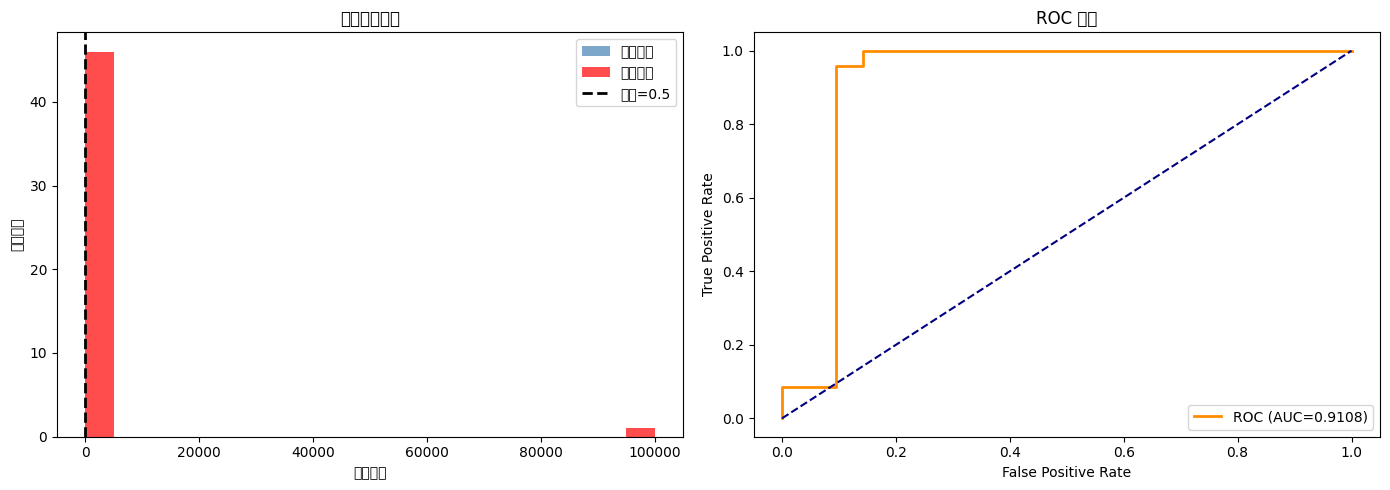


各閾值對應的準確率（供閾值調整參考）：
        閾值 |      正確率 |      召回率(異常) |      誤報率(正常)
--------------------------------------------------
    5.2165 |   79.41% |      100.00% |       66.67%
    6.7870 |   89.71% |      100.00% |       33.33%
    7.1577 |   94.12% |       95.74% |        9.52%
    7.2047 |   85.29% |       82.98% |        9.52%
    7.3094 |   75.00% |       68.09% |        9.52%
    7.3204 |   64.71% |       53.19% |        9.52%
    7.3292 |   55.88% |       40.43% |        9.52%
    7.3372 |   45.59% |       25.53% |        9.52%
    7.3468 |   35.29% |       10.64% |        9.52%


In [27]:
from sklearn.metrics import roc_curve

scores_arr = np.array(all_scores)
labels_arr = np.array(all_labels)

# --- AUC-ROC ---
if len(np.unique(labels_arr)) > 1:
    auc = roc_auc_score(labels_arr, scores_arr)
    fpr, tpr, thresholds = roc_curve(labels_arr, scores_arr)
    print(f"AUC-ROC：{auc:.4f}")
else:
    print("警告：標籤只有一類，無法計算 AUC")
    fpr, tpr, thresholds = None, None, None

# --- 分數分布圖 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

normal_scores  = scores_arr[labels_arr == 0]
anomaly_scores = scores_arr[labels_arr == 1]

axes[0].hist(normal_scores,  bins=20, alpha=0.7, color="steelblue", label="正常影片")
axes[0].hist(anomaly_scores, bins=20, alpha=0.7, color="red",       label="異常影片")
axes[0].axvline(x=ANOMALY_THRESHOLD, color="black", linestyle="--", linewidth=2, label=f"閾值={ANOMALY_THRESHOLD}")
axes[0].set_title("異常分數分布")
axes[0].set_xlabel("異常分數")
axes[0].set_ylabel("影片數量")
axes[0].legend()

# --- ROC 曲線 ---
if fpr is not None:
    axes[1].plot(fpr, tpr, color="darkorange", linewidth=2, label=f"ROC (AUC={auc:.4f})")
    axes[1].plot([0, 1], [0, 1], color="navy", linestyle="--")
    axes[1].set_title("ROC 曲線")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend()

plt.tight_layout()
plt.show()

# --- 各閾值的 Precision / Recall ---
print("\n各閾值對應的準確率（供閾值調整參考）：")
print(f"{'閾值':>10} | {'正確率':>8} | {'召回率(異常)':>12} | {'誤報率(正常)':>12}")
print("-" * 50)

candidate_thresholds = np.percentile(scores_arr, np.arange(10, 100, 10))
for t in sorted(set(candidate_thresholds)):
    preds = (scores_arr > t).astype(int)
    if len(np.unique(labels_arr)) > 1:
        tp = ((preds == 1) & (labels_arr == 1)).sum()
        fp = ((preds == 1) & (labels_arr == 0)).sum()
        fn = ((preds == 0) & (labels_arr == 1)).sum()
        tn = ((preds == 0) & (labels_arr == 0)).sum()
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr_val = fp / (fp + tn) if (fp + tn) > 0 else 0
        acc = (tp + tn) / len(labels_arr)
        print(f"{t:>10.4f} | {acc:>8.2%} | {recall:>12.2%} | {fpr_val:>12.2%}")

## Cell 15 — 混淆矩陣（使用當前閾值）

C:\Users\user\AppData\Local\Temp\ipykernel_63112\1187478554.py:10: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\1187478554.py:10: UserWarning: Glyph 24120 (\N{CJK UNIFIED IDEOGRAPH-5E38}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\1187478554.py:10: UserWarning: Glyph 30064 (\N{CJK UNIFIED IDEOGRAPH-7570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\1187478554.py:10: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\1187478554.py:10: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_63112\1187478554.py:10: UserWarning: Glyph 30697 (\N{CJK 

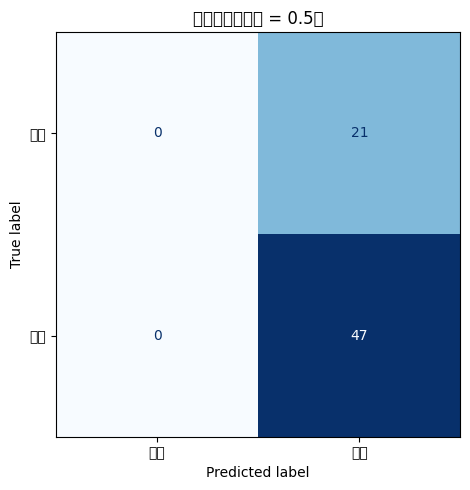

True Positive  (正確偵測異常)：47
True Negative  (正確判斷正常)：0
False Positive (誤報，正常被判異常)：21
False Negative (漏報，異常未被偵測)：0


In [31]:
# 用目前設定的 ANOMALY_THRESHOLD 產生混淆矩陣
preds = (scores_arr > ANOMALY_THRESHOLD).astype(int)

cm = confusion_matrix(labels_arr, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["正常", "異常"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"混淆矩陣（閾值 = {ANOMALY_THRESHOLD}）")
plt.tight_layout()
plt.show()

# 印出詳細數字
tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)
print(f"True Positive  (正確偵測異常)：{tp}")
print(f"True Negative  (正確判斷正常)：{tn}")
print(f"False Positive (誤報，正常被判異常)：{fp}")
print(f"False Negative (漏報，異常未被偵測)：{fn}")

## Cell 16 — 互動式閾值調整
修改 `NEW_THRESHOLD` 並重新執行此 Cell 來即時查看效果

In [30]:
# 修改這個值來調整閾值
NEW_THRESHOLD = 7

preds_new = (scores_arr > NEW_THRESHOLD).astype(int)
cm_new = confusion_matrix(labels_arr, preds_new)

if cm_new.size == 4:
    tn, fp, fn, tp = cm_new.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    accuracy  = (tp + tn) / len(labels_arr)
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"閾值：{NEW_THRESHOLD}")
    print(f"  準確率 (Accuracy)  ：{accuracy:.2%}")
    print(f"  召回率 (Recall)    ：{recall:.2%}  ← 抓到幾成異常")
    print(f"  精確率 (Precision) ：{precision:.2%} ← 判異常時正確率")
    print(f"  F1 Score           ：{f1:.4f}")
    print(f"  誤報數 (FP)        ：{fp} 支正常影片被誤判")
    print(f"  漏報數 (FN)        ：{fn} 支異常影片未被偵測")
else:
    print("標籤種類不足，無法計算完整指標")

閾值：7
  準確率 (Accuracy)  ：95.59%
  召回率 (Recall)    ：100.00%  ← 抓到幾成異常
  精確率 (Precision) ：94.00% ← 判異常時正確率
  F1 Score           ：0.9691
  誤報數 (FP)        ：3 支正常影片被誤判
  漏報數 (FN)        ：0 支異常影片未被偵測


## Cell 17 — 批次推論新影片（實際使用）

In [ ]:
def batch_inference(video_dir: str, knn, threshold: float = ANOMALY_THRESHOLD):
    """
    對整個資料夾的影片批次推論
    輸出每支影片的判斷結果
    """
    video_paths = get_video_paths(video_dir)
    print(f"共 {len(video_paths)} 支影片待分析\n")
    
    results = []
    for vp in video_paths:
        r = analyze_video(vp, knn, threshold=threshold)
        if r:
            results.append(r)
    
    print("\n" + "=" * 50)
    print("批次推論結果總覽：")
    print(f"{'影片名稱':<30} {'結果':<8} {'異常分數':>10} {'Stage1':>8}")
    print("-" * 60)
    for r in results:
        name   = Path(r["video_path"]).name[:28]
        status = "🔴 異常" if r["is_anomaly"] else "🟢 正常"
        s1     = "⚠️ 是" if r["stage1_triggered"] else "否"
        print(f"{name:<30} {status:<8} {r['anomaly_score']:>10.4f} {s1:>8}")
    
    n_anomaly = sum(1 for r in results if r["is_anomaly"])
    print(f"\n正常：{len(results) - n_anomaly} 支 | 異常：{n_anomaly} 支")
    return results


# 修改成你要分析的影片資料夾
# INFERENCE_DIR = "./data/new_videos"
# inference_results = batch_inference(INFERENCE_DIR, knn_index, threshold=ANOMALY_THRESHOLD)